In [1]:
# Autoreload
%load_ext autoreload
%autoreload 2

from optimizer import Optimizer
from chromosome import Chromosome
from character import Character
from utils import get_item_set,elements
import json

with open('data/MAPPED_ITEMS.json', 'r') as file:
    items = {i["ankama_id"]: i for i in json.load(file)}

with open('data/MAPPED_SETS.json', 'r') as file:
    item_sets = {i["ankama_id"]: i for i in json.load(file)}

In [ ]:
config = {
            "optimizer" : {
                "language": "es",
                "population_size": 300,
                "num_parents_mating": 100, # Number of parents to mate, usually 30%
                "num_generations": 400,
                "mutation_rate": 0.05,
                "crossover_rate": 0.8,
                "parent_selection_type": "tournament",  # Tournament Selection
                "tournament_size": 3,
                "exclusions": {
                    "items": [
                        6894, # GM pet
                        6895, # GM pet
                        3080, # GM pet
                        9031, # GM pet
                        6980, # Vulbis
                        31886, # Venerable petmount
                              ]  # Excluded items
                },
                "inclusions": {
                    "items": [
                        22206, # Alianza de corrupcion
                        22205, # Anillo de corrupcion
                        31763, # Ferhoz
                              ]
                },
                "preferences": {
                    "lower": {
                        12: {
                            "target": 12,  # AP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        8: {
                            "target": 6,  # MP
                            "strength": 0.9,  # Penalty for not meeting the target
                        },
                        # 29: {
                        #     "target": 70,  # Crit
                        #     "strength": 0.75,  # Penalty for not meeting the target
                        # }, 
                        9: {
                            "target": 4000,  # Vit
                            "strength": 0.5,  # Penalty for not meeting the target
                        }, 
                        28 : {
                            "target": 6, # Summons
                            "strength": 0.75,  # Penalty for not meeting the target
                        },
                        34 : {
                            "target": 15, # %res neutral
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        37 : {
                            "target": 15, # %res fire
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        16 : {
                            "target": 15, # %res air
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        17 : {
                            "target": 15, # %res water
                            "strength": 0.1,  # Penalty for not meeting the target
                        },
                        63 : {
                            "target": 15, # %res range
                            "strength": 0.1,  # Penalty for not meeting the target
                        }
                    },
                    "upper": {} 
                },
                "elements" : [
                    36, # Agility,
                    # 22, # Chance
                    # 13, # Intelligence
                    45  # Strength
                ],
                "level_offset": 10,  # Level offset for items
                "objective": "weapon"  # Objective to optimize, can be "weapon" or "elements"
            },
            "character": {
                "level": 200,
                "scrolled": True,
                "exo": {
                    12:1, # Exo AP
                    28:1, # Exo Summons
                    # 8:1
                    },  # Exo MP
                "distributed_points": {
                    # 45: 995,  # Strength
                }
            },
        }

In [14]:
import pandas as pd

effect_descriptions = {}
for _,item in items.items():
    if not item["effects"]:
        continue
    for effect in item["effects"]:
        effect_descriptions[effect["element_id"]] = effect["type"]

dct = {}
for k,v in items.items():
    item_set = get_item_set(v,item_sets)
    dct[k] = {
        "name" : v["name"][config["optimizer"]["language"]],
        "set" : item_set["name"][config["optimizer"]["language"]] if item_set else None,
        "level" : v["level"]
    }
Items = pd.DataFrame.from_dict(dct, orient='index')
# Exclude items from the Gargandias set
config["optimizer"]["exclusions"]["items"] += Items[Items["set"].str.contains("Set de Gargandias",na=False,case=False)].index.tolist()

In [15]:
char = Character(**config["character"])
opt = Optimizer(char,
                 items,
                   item_sets,
                     **config["optimizer"])

Total items: 2743
Total item sets: 147
Total pools:
   16 with sizes [68, 1, 1, 1, 62, 81, 39, 88, 69, 411, 326, 326, 326, 326, 326, 326]
Total combinations: 10^28.60


In [16]:
char.stats

{36: 266,
 22: 266,
 13: 266,
 45: 266,
 9: 1150,
 12: 8,
 8: 3,
 252: 1,
 10: 100,
 28: 1}

In [5]:
solutions = opt.optimize(islands = 10, max_workers = 4)

In [6]:
for idx, solution in enumerate(sorted(solutions, key=lambda x: x.fitness, reverse=True)):
    if solution.penalized:
        continue
    print(f"Solution {idx}:")
    print("\tFitness:", solution.get_fitness())
    print("\tWeapon damage:", solution.get_final_weapon_damage())
    print("\tElemental damage:", solution.get_final_elemental_damage())
    # print("\tIs the solution viable?", solution.viable)
    # print("\tWas the solution penalized?", solution.penalized)

    print("\tPreferences:")
    df = solution.totals_summary(effect_descriptions)
    for bound, preference in solution.preferences.items():
        for element, details in preference.items():
            row = df.loc[element]
            print(f"\t\t{row['description']} : {row['value']}")
    print("\tCharacteristics:")
    for element in elements:
        print(f"\t\t{df.loc[element]['description']}: {df.loc[element]['value']}")

    print("\tItems:")
    print("\t\tType\tDescription\tLevel")
    for item,row in solution.set_summary().sort_values("type").iterrows():
        # Prettify the output
        print(f"\t\t{row['type']}\t{row['description']}\t{row['level']}")

Solution 0:
	Fitness: 935.8799999999999
	Weapon damage: 935.8799999999999
	Elemental damage: 705.4
	Preferences:
		PA : 12.0
		PM : 6.0
		vitalidad : 4200.0
		invocaciones : 7.0
		% resistencia neutral : 15.0
		% resistencia al fuego : 22.0
		% resistencia al aire : 17.0
		% resistencia al agua : 31.0
		% resistencia a la tierra : 24.0
	Characteristics:
		agilidad: 576.0
		suerte: 386.0
		inteligencia: 376.0
		fuerza: 856.0
		vitalidad: 4200.0
		sabiduría: 430.0
	Items:
		Type	Description	Level
		Amuleto	Amuleto de kukoloide	200
		Anillo	Anillo de Corrupción	200
		Anillo	Alianza de Corrupción	200
		Bota	Botas Jotdog-o	200
		Capa	Velameba	200
		Cinturón	Cinturón de la Reina de los Ladrones	200
		Dofus	Dofus Púrpura	110
		Dofus	Dofus de los hielos	180
		Dofus	Dofus Ocre	160
		Escudo	Escudo poseído	200
		Guadaña	Ferhoz	200
		Mascota	Feanor	20
		Sombrero	Sombrero de la Reina de los Ladrones	200
		Trofeo	Robusto mayor	150
		Trofeo	Lozano mayor	150
		Trofeo	Espabilador	100
Solution 1:
	Fitne

In [7]:
solutions[0].get_final_weapon_damage()

932.48

In [8]:
solution.totals_summary(effect_descriptions).sort_values("description",ascending=False)

,description,value
9,vitalidad,4150.0
22,suerte,336.0
10,sabiduría,470.0
25,prospección,65.0
32,potencia (daños generales),410.0
26,placaje,37.0
28,invocaciones,6.0
13,inteligencia,266.0
24,iniciativa,300.0
59,huida,12.0


In [9]:
set_summary = solution.set_summary()
set_summary

,type_id,type,description,level,set
694,13,Dofus,Dofus Púrpura,110,None
7043,13,Dofus,Dofus de los hielos,180,None
11955,12,Mascota,Bulbesor,20,None
13828,13,Trofeo,Robusto mayor,150,None
15692,5,Bota,Ballenotas,200,Set de la ballena
15699,4,Cinturón,Cintáceo,200,Set de la ballena
15701,1,Amuleto,Amuleto de Pol Guatson,200,Set de Pol Guatson
16332,13,Trofeo,Lozano mayor,150,None
16335,13,Trofeo,Nómada,100,None
16339,13,Trofeo,Sanguinario mayor,150,None


Text(0, 0.5, 'Best Fitness')

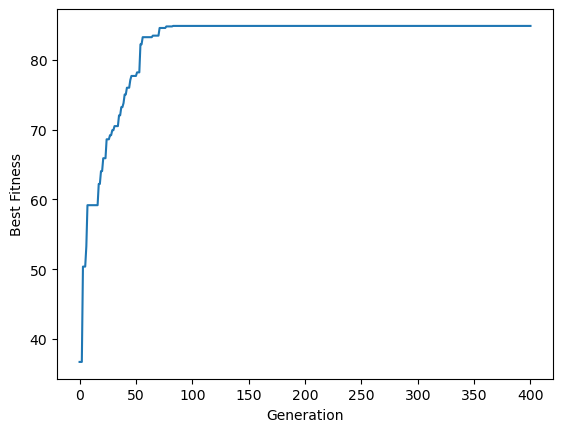

In [10]:
import matplotlib.pyplot as plt
plt.plot(solution.best_solutions_fitness)
plt.xlabel('Generation')
plt.ylabel('Best Fitness')

In [11]:
assert False

AssertionError: 

In [ ]:
Items[Items["name"].str.contains("anillo de corrupc",case=False)]

,name,set,level
22205,Anillo de Corrupción,Set de Corrupción,200


In [ ]:
# Current
chr = Chromosome([
                    8993, # Espada
                    13641, 13643, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    19985, # Vuelo
                    18670, # Escudo
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

1890.67

In [ ]:
Items[Items["name"].str.contains("kuko")]

,name,set,level
13989,Pluma de kukoloide,None,200
14091,Amuleto de kukoloide,Set de kukoloide,200
14092,Anillo de kukoloide,Set de kukoloide,200
14093,Botas de kukoloide,Set de kukoloide,200
13988,Ojo de kukoloide,None,200
18718,Escudo de kukoloide,Set de kukoloide,200


In [ ]:
# Project
chr = Chromosome(
                 [
                    8993, # Espada
                    13641, 13642, # Noai
                    14161, 14162, 14169, # Charlatan
                    14092, 14093, 18718, # Kuko
                    13673, # Lokulto
                    739, 694, 7754, 737, 7043, 17078 # Dofus
                 ],
                 opt)
chr.fitness

2049.74

In [ ]:
chr.set_summary()

In [ ]:
chr.set_summary()["set"].value_counts()

In [ ]:
chr.totals_summary(effect_descriptions)

In [ ]:
Items[Items["name"].str.contains("Chani")]

In [ ]:
item = items[21392]
# item = items[6981]

In [ ]:
chr.are_item_conditions_met(item)

In [ ]:
item

In [ ]:
Items

In [ ]:
lst

In [ ]:
lst[0][2]

In [ ]:
chr.are_item_conditions_met(items[11738])

In [ ]:
items[11738]["conditions"]

In [ ]:
chr.totals[8]

In [ ]:
lst = []
for i in items.values():
    if i["type"]["superTypeId"] not in [i[0] for i in opt.pool_types]:
        continue
    if i["conditions"]:
        print(opt.solution.are_item_conditions_met(i))
        lst.append((i,opt.solution.are_item_conditions_met(i)))

In [ ]:
lst[1]

In [ ]:
lst.count(True), lst.count(False)